In [1]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import torchvision
import numpy as np
import pandas as pd
import sklearn
import PIL

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.13.0+cpu
Torchvision: 0.28.0+cpu
CUDA available: False


In [4]:
import os, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

%matplotlib inline

## Configuration

In [5]:
CONFIG = {
    "seed": 42,
    "data_root": "../data/Sanskrit Mnist/images",
    "image_size": 32,
    "batch_size": 128,
    "val_split": 0.1,
    "lr": 1e-3,
    "epochs": 3,          # FIRST RUN ONLY
    "dropout_p": 0.3,
    "num_workers": 0,
}


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(CONFIG["seed"])

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
print(CONFIG)

Device: cpu
{'seed': 42, 'data_root': '../data/Sanskrit Mnist/images', 'image_size': 32, 'batch_size': 128, 'val_split': 0.1, 'lr': 0.001, 'epochs': 3, 'dropout_p': 0.3, 'num_workers': 0}


## Dataset Overview


In [6]:
TRAIN_DIR = CONFIG["data_root"]
TEST_DIR = CONFIG["data_root"]


def scan_split(split_dir):
    class_dirs = sorted(
        [d for d in os.scandir(split_dir) if d.is_dir()],
        key=lambda d: d.name
    )

    return {
        d.name: [
            f.path
            for f in os.scandir(d.path)
            if f.name.lower().endswith(
                (".png", ".jpg", ".jpeg")
            )
        ]
        for d in class_dirs
    }


all_files = scan_split(TRAIN_DIR)

train_files = all_files
test_files = all_files

class_names = sorted(train_files.keys())
num_classes = len(class_names)

print(f"Classes ({num_classes}): {class_names[:10]} ...")
print(f"Total images: {sum(len(v) for v in train_files.values())}")

if num_classes != 46:
    print(
        f"NOTE: expected 46 classes, found {num_classes}."
    )

Classes (62): ['00_a', '01_aa', '02_i', '03_ii', '04_u', '05_uu', '06_ri', '07_rii', '08_li', '09_e'] ...
Total images: 31000
NOTE: expected 46 classes, found 62.


## Exploratory Data Analysis

### Class Distribution

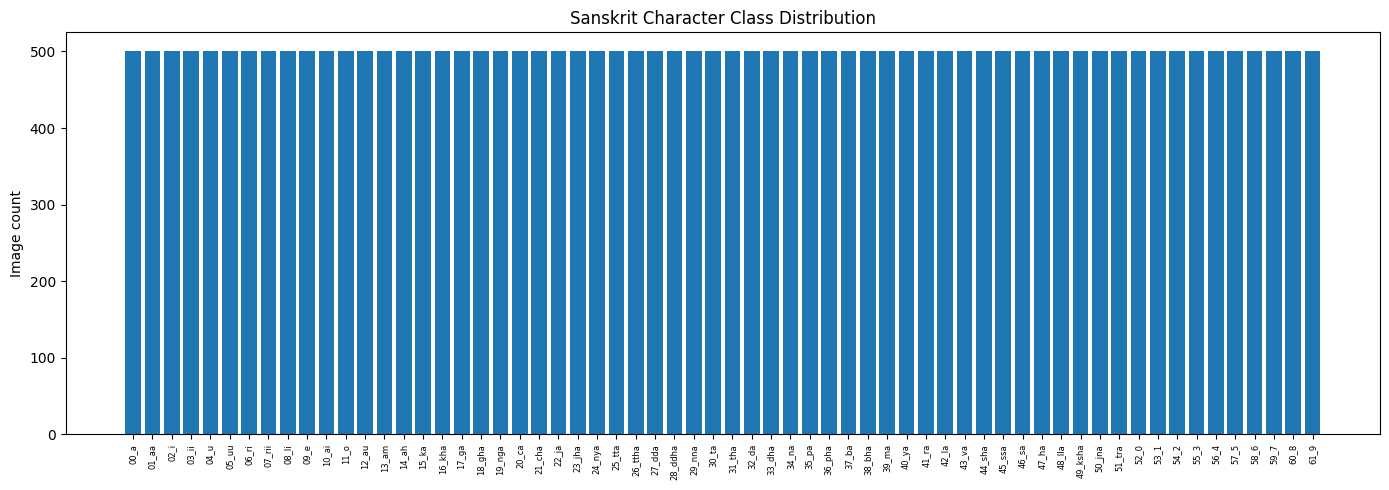

Per-class count: min=500 max=500 mean=500.0


In [20]:
train_counts = {
    k: len(v)
    for k, v in train_files.items()
}

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    range(num_classes),
    [train_counts[c] for c in class_names]
)

ax.set_xticks(range(num_classes))
ax.set_xticklabels(
    class_names,
    rotation=90,
    fontsize=6
)

ax.set_ylabel("Image count")
ax.set_title("Sanskrit Character Class Distribution")

plt.tight_layout()
plt.show()

vals = list(train_counts.values())

print(
    f"Per-class count: "
    f"min={min(vals)} "
    f"max={max(vals)} "
    f"mean={np.mean(vals):.1f}"
)

### Sample Images


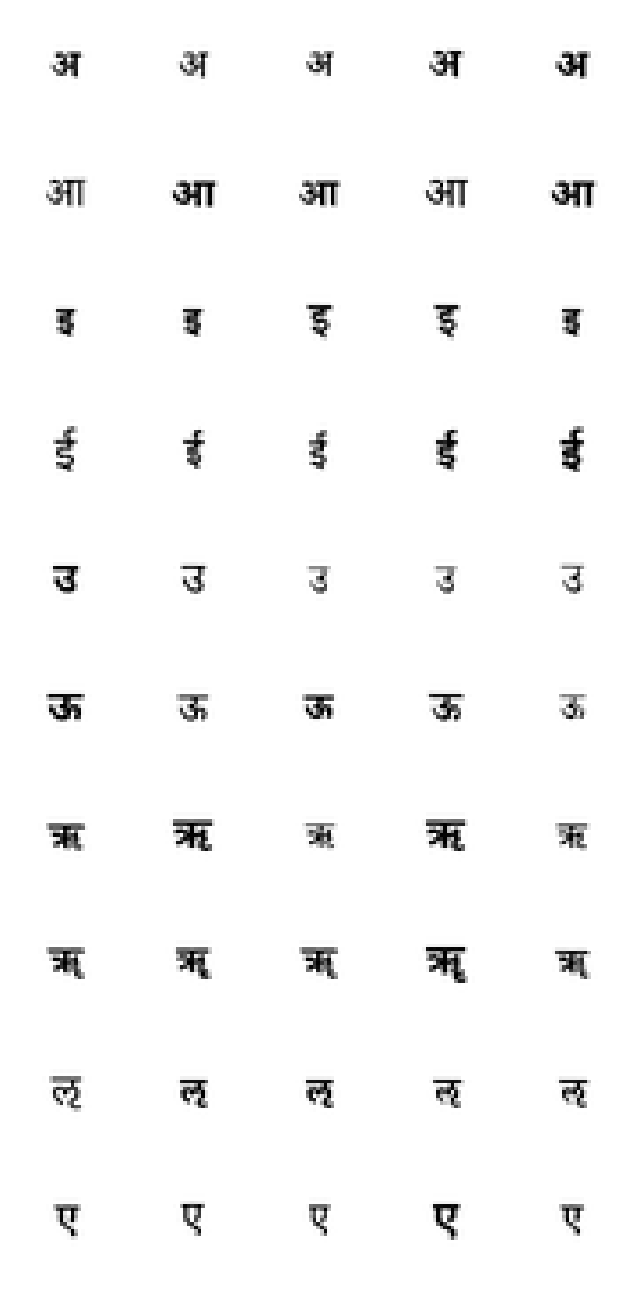

In [28]:
def plot_sample_grid(
    files_dict,
    classes,
    samples_per_class=5
):
    
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(samples_per_class * 1.3, len(classes) * 1.3))
    for r, cls in enumerate(classes):
        for c in range(samples_per_class):
            ax = axes[r, c]
            if c < len(files_dict[cls]):
                img = Image.open(files_dict[cls][c]).convert("L")
                ax.imshow(img,cmap="gray")
            ax.axis("off")

            if c == 0:
                ax.set_ylabel(cls,rotation=0,ha="right",fontsize=6)
    plt.tight_layout()
    plt.show()

plot_sample_grid(
    train_files,
    class_names[:10],
    samples_per_class=5
)

### Image Properties

In [29]:
dims = {}
modes = {}

pix_min = 255
pix_max = 0

for cls, files in train_files.items():
    for f in files[:5]:
        with Image.open(f) as img:
            dims[img.size] = (dims.get(img.size, 0) + 1)
            modes[img.mode] = (modes.get(img.mode, 0) + 1)
            arr = np.array(img.convert("L"))
            pix_min = min(pix_min,int(arr.min()))
            pix_max = max(pix_max,int(arr.max()))

print("Dimensions seen:", dims)
print("Modes seen:", modes)
print(f"Pixel range: {pix_min}-{pix_max}")
if len(dims) > 1:
    print("WARNING: images have different " "dimensions; resizing will be applied.")

Dimensions seen: {(32, 32): 310}
Modes seen: {'L': 310}
Pixel range: 0-255


## Preprocessing

In [ ]:
def compute_mean_std(train_dir, image_size, sample_cap=5000):
    tfm = transforms.Compose([
        transforms.Grayscale(1),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor()
    ])
    ds = datasets.ImageFolder(train_dir, transform=tfm)
    rng = np.random.default_rng(CONFIG["seed"])
    idx = rng.choice(len(ds), size=min(sample_cap, len(ds)), replace=False)
    s = 0.0
    sq = 0.0
    n = 0
    for i in idx:
        arr = ds[i][0].numpy()
        s += arr.sum()
        sq += (arr ** 2).sum()
        n += arr.size
    mean = s / n
    std = float(np.sqrt(max(sq / n - mean ** 2, 1e-12)))
    return mean, std

MEAN, STD = compute_mean_std(TRAIN_DIR, CONFIG["image_size"])
print(f"Computed mean={MEAN:.4f}, std={STD:.4f}")

Computed mean=0.9661, std=0.1106


### Training & Evaluation Transforms

In [30]:
def compute_mean_std(train_dir, image_size, sample_cap=5000):
    tfm = transforms.Compose([
        transforms.Grayscale(1),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor()
    ])
    ds = datasets.ImageFolder(train_dir, transform=tfm)
    rng = np.random.default_rng(CONFIG["seed"])
    idx = rng.choice(len(ds), size=min(sample_cap, len(ds)), replace=False)
    s = 0.0
    sq = 0.0
    n = 0
    for i in idx:
        arr = ds[i][0].numpy()
        s += arr.sum()
        sq += (arr ** 2).sum()
        n += arr.size
    mean = s / n
    std = float(np.sqrt(max(sq / n - mean ** 2, 1e-12)))
    return mean, std

MEAN, STD = compute_mean_std(TRAIN_DIR, CONFIG["image_size"])
print(f"Computed mean={MEAN:.4f}, std={STD:.4f}")

Computed mean=0.9661, std=0.1106


## Train / Validation / Test Split

In [ ]:
def make_train_val_test_datasets(val_split=0.1, test_split=0.1, seed=42):
    full_dataset = datasets.ImageFolder(TRAIN_DIR)
    targets = np.array([s[1] for s in full_dataset.samples])
    indices = np.arange(len(targets))

    train_idx, temp_idx = train_test_split(
        indices,
        test_size=val_split + test_split,
        stratify=targets,
        random_state=seed
    )

    temp_targets = targets[temp_idx]
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.5,
        stratify=temp_targets,
        random_state=seed
    )

    train_full = datasets.ImageFolder(TRAIN_DIR, transform=train_tfm)
    eval_full = datasets.ImageFolder(TRAIN_DIR, transform=eval_tfm)
    assert train_full.classes == eval_full.classes == class_names
    train_ds = Subset(train_full, train_idx)
    val_ds = Subset(eval_full, val_idx)
    test_ds = Subset(eval_full, test_idx)
    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = make_train_val_test_datasets(
    val_split=0.1,
    test_split=0.1,
    seed=CONFIG["seed"]
)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 24800 | Val: 3100 | Test: 3100


## DataLoaders

In [ ]:
def make_loaders(train_ds, val_ds, test_ds, batch_size=CONFIG["batch_size"]):
    return (
        DataLoader(
            train_ds,
            batch_size=batch_size,
            shuffle=True,
            num_workers=CONFIG["num_workers"]
        ),
        DataLoader(
            val_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=CONFIG["num_workers"]
        ),
        DataLoader(
            test_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=CONFIG["num_workers"]
        )
    )

train_loader, val_loader, test_loader = make_loaders(
    train_ds,
    val_ds,
    test_ds
)

xb, yb = next(iter(train_loader))

print("Batch shape:", xb.shape, "| dtype:", xb.dtype)

Batch shape: torch.Size([128, 1, 32, 32]) | dtype: torch.float32


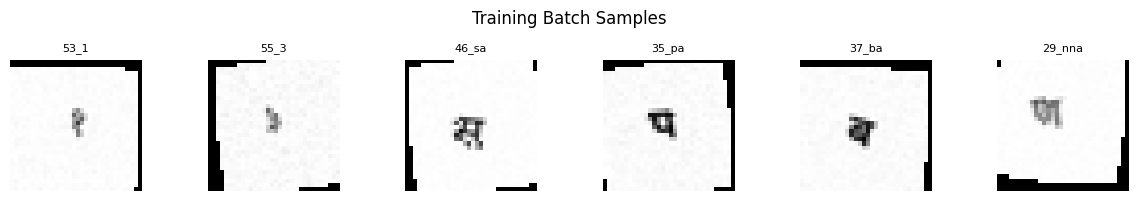

In [31]:
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i, ax in enumerate(axes):
    img = xb[i][0] * STD + MEAN
    ax.imshow(img, cmap="gray")
    ax.set_title(class_names[yb[i].item()], fontsize=8)
    ax.axis("off")
plt.suptitle("Training Batch Samples")
plt.tight_layout()
plt.show()

## Custom CNN



In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_bn, pool):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=not use_bn)
        self.bn = nn.BatchNorm2d(out_ch) if use_bn else nn.Identity()
        self.pool = nn.MaxPool2d(2) if pool else nn.Identity()
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = F.relu(x)
        x = self.pool(x)
        return x

class CustomCNN(nn.Module):
    def __init__(self, num_classes, use_batchnorm=True, use_dropout=True, dropout_p=0.3):
        super().__init__()
        self.block1 = ConvBlock(1, 32, use_batchnorm, pool=True)
        self.block2 = ConvBlock(32, 64, use_batchnorm, pool=True)
        self.block3 = ConvBlock(64, 128, use_batchnorm, pool=False)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout_p) if use_dropout else nn.Identity()
        self.fc = nn.Linear(128, num_classes)
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

In [ ]:
m = CustomCNN(num_classes, use_batchnorm=True, use_dropout=True).to(DEVICE)
out = m(xb.to(DEVICE))
num_params = sum(p.numel() for p in m.parameters())
print("Output shape:", out.shape)
print("Parameters:", num_params)

Output shape: torch.Size([128, 62])
Parameters: 100894


## Training Pipeline

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        if train:
            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                outputs = model(images)
                loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

def train_model(model, train_loader, val_loader, epochs=CONFIG["epochs"], lr=CONFIG["lr"], patience=3, ckpt_path=None, verbose=True):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -1
    best_epoch = -1
    no_improve = 0
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer=optimizer, train=True)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, train=False)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f} | {time.time() - t0:.1f}s")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            no_improve = 0
            if ckpt_path:
                os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
                torch.save({"state_dict": model.state_dict(), "class_names": class_names, "image_size": CONFIG["image_size"], "mean": MEAN, "std": STD}, ckpt_path)
                print(f"   -> new best model saved (val_acc={val_acc:.4f})")
        else:
            no_improve += 1
            if patience and no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
    return history, best_val_acc, best_epoch

## Baseline CNN

In [32]:
CONFIG["epochs"] = 10

set_seed(CONFIG["seed"])

baseline_model = CustomCNN(
    num_classes,
    use_batchnorm=False,
    use_dropout=False
).to(DEVICE)

baseline_history, baseline_best_acc, baseline_best_epoch = train_model(
    baseline_model,
    train_loader,
    val_loader,
    epochs= 10,
    lr=1e-3,
    patience=3,
    ckpt_path="../models/baseline_best.pth"
)

print(
    f"\nBaseline best val_acc="
    f"{baseline_best_acc:.4f} "
    f"@ epoch {baseline_best_epoch}"
)

Epoch 01 | train_loss=4.0979 train_acc=0.0214 | val_loss=3.8960 val_acc=0.0394 | 30.9s
   -> new best model saved (val_acc=0.0394)
Epoch 02 | train_loss=3.5041 train_acc=0.0781 | val_loss=3.2799 val_acc=0.1006 | 33.1s
   -> new best model saved (val_acc=0.1006)
Epoch 03 | train_loss=2.7249 train_acc=0.2212 | val_loss=2.2105 val_acc=0.3752 | 38.5s
   -> new best model saved (val_acc=0.3752)
Epoch 04 | train_loss=1.9023 train_acc=0.4422 | val_loss=1.5197 val_acc=0.5200 | 38.1s
   -> new best model saved (val_acc=0.5200)
Epoch 05 | train_loss=1.3772 train_acc=0.5886 | val_loss=1.0195 val_acc=0.6913 | 36.2s
   -> new best model saved (val_acc=0.6913)
Epoch 06 | train_loss=1.0528 train_acc=0.6856 | val_loss=0.7867 val_acc=0.7810 | 37.7s
   -> new best model saved (val_acc=0.7810)
Epoch 07 | train_loss=0.8541 train_acc=0.7432 | val_loss=0.6618 val_acc=0.7890 | 36.1s
   -> new best model saved (val_acc=0.7890)
Epoch 08 | train_loss=0.7125 train_acc=0.7834 | val_loss=0.4957 val_acc=0.8697 | 36

In [32]:
noaug_train_full = datasets.ImageFolder(TRAIN_DIR, transform=train_tfm_noaug)
noaug_train_ds = Subset(noaug_train_full, train_ds.indices)
noaug_train_loader = DataLoader(noaug_train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
print(f"No-augmentation train loader ready: {len(noaug_train_ds)} images")

No-augmentation train loader ready: 24800 images


## Regularization: BatchNorm + Dropout

In [34]:
set_seed(CONFIG["seed"])

reg_model = CustomCNN(
    num_classes,
    use_batchnorm=True,
    use_dropout=True,
    dropout_p=CONFIG["dropout_p"]
).to(DEVICE)

reg_history, reg_best_acc, reg_best_epoch = train_model(
    reg_model,
    noaug_train_loader,
    val_loader,
    epochs=10,
    lr=1e-3,
    patience=3,
    ckpt_path="../models/regularized_best.pth"
)

print(f"\nRegularized best val_acc={reg_best_acc:.4f} @ epoch {reg_best_epoch}")
print(f"(Baseline was {baseline_best_acc:.4f})")

Epoch 01 | train_loss=3.2475 train_acc=0.2759 | val_loss=2.2066 val_acc=0.6403 | 36.4s
   -> new best model saved (val_acc=0.6403)
Epoch 02 | train_loss=1.4815 train_acc=0.7629 | val_loss=1.0094 val_acc=0.8571 | 37.0s
   -> new best model saved (val_acc=0.8571)
Epoch 03 | train_loss=0.7111 train_acc=0.8946 | val_loss=0.6500 val_acc=0.8642 | 36.9s
   -> new best model saved (val_acc=0.8642)
Epoch 04 | train_loss=0.4311 train_acc=0.9322 | val_loss=0.3498 val_acc=0.9368 | 35.6s
   -> new best model saved (val_acc=0.9368)
Epoch 05 | train_loss=0.2988 train_acc=0.9514 | val_loss=0.3171 val_acc=0.9361 | 36.3s
Epoch 06 | train_loss=0.2186 train_acc=0.9640 | val_loss=0.3436 val_acc=0.8977 | 35.9s
Epoch 07 | train_loss=0.1735 train_acc=0.9718 | val_loss=0.1769 val_acc=0.9606 | 36.5s
   -> new best model saved (val_acc=0.9606)
Epoch 08 | train_loss=0.1407 train_acc=0.9756 | val_loss=0.1116 val_acc=0.9784 | 36.5s
   -> new best model saved (val_acc=0.9784)
Epoch 09 | train_loss=0.1168 train_acc=0

## Data Augmentation

In [35]:
set_seed(CONFIG["seed"])

aug_model = CustomCNN(
    num_classes,
    use_batchnorm=True,
    use_dropout=True,
    dropout_p=CONFIG["dropout_p"]
).to(DEVICE)

aug_history, aug_best_acc, aug_best_epoch = train_model(
    aug_model,
    train_loader,          # augmented
    val_loader,
    epochs=10,
    lr=1e-3,
    patience=3,
    ckpt_path="../models/augmented_best.pth"
)

print(f"\nAugmented best val_acc={aug_best_acc:.4f} @ epoch {aug_best_epoch}")

Epoch 01 | train_loss=3.8136 train_acc=0.0713 | val_loss=3.2043 val_acc=0.1597 | 45.7s
   -> new best model saved (val_acc=0.1597)
Epoch 02 | train_loss=2.5432 train_acc=0.3822 | val_loss=2.2384 val_acc=0.3439 | 49.7s
   -> new best model saved (val_acc=0.3439)
Epoch 03 | train_loss=1.5360 train_acc=0.6605 | val_loss=1.0129 val_acc=0.8168 | 51.6s
   -> new best model saved (val_acc=0.8168)
Epoch 04 | train_loss=0.9757 train_acc=0.7832 | val_loss=0.8471 val_acc=0.7710 | 38.6s
Epoch 05 | train_loss=0.7185 train_acc=0.8294 | val_loss=0.6695 val_acc=0.7990 | 37.2s
Epoch 06 | train_loss=0.5702 train_acc=0.8575 | val_loss=0.5141 val_acc=0.8455 | 41.7s
   -> new best model saved (val_acc=0.8455)
Epoch 07 | train_loss=0.4695 train_acc=0.8812 | val_loss=0.4996 val_acc=0.8442 | 37.1s
Epoch 08 | train_loss=0.4057 train_acc=0.8944 | val_loss=0.2174 val_acc=0.9535 | 36.5s
   -> new best model saved (val_acc=0.9535)
Epoch 09 | train_loss=0.3686 train_acc=0.9019 | val_loss=0.2736 val_acc=0.9200 | 38.

### Experiment Comparison

,experiment,BN,Dropout,Augment,val_acc
0,Baseline,False,False,False,0.892258
1,BatchNorm + Dropout,True,True,False,0.978387
2,BN + Dropout + Augment,True,True,True,0.953548


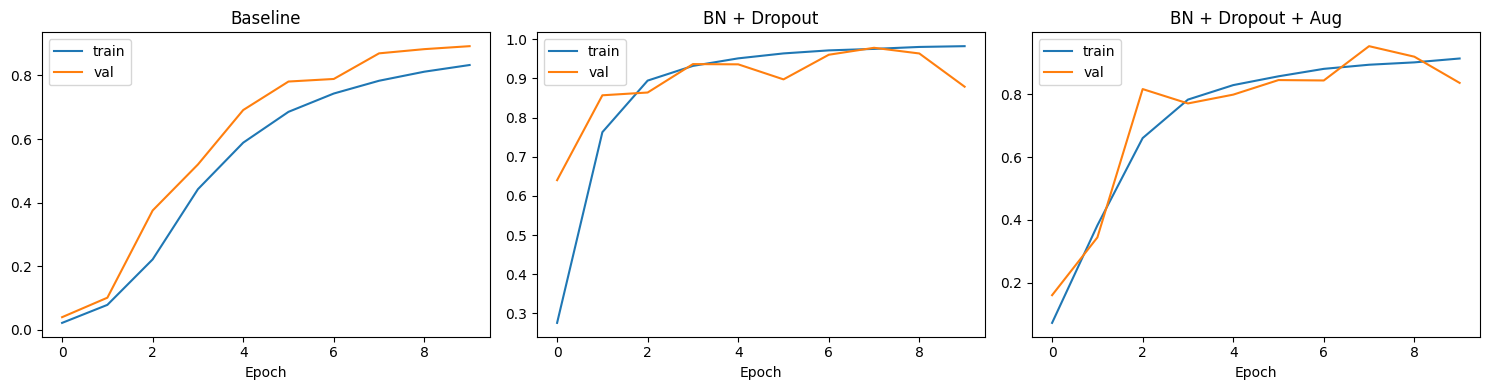

In [36]:
ablation_df = pd.DataFrame([
    {"experiment": "Baseline",              "BN": False, "Dropout": False, "Augment": False, "val_acc": baseline_best_acc},
    {"experiment": "BatchNorm + Dropout",   "BN": True,  "Dropout": True,  "Augment": False, "val_acc": reg_best_acc},
    {"experiment": "BN + Dropout + Augment","BN": True,  "Dropout": True,  "Augment": True,  "val_acc": aug_best_acc},
])
display(ablation_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (hist, title) in zip(axes, [
    (baseline_history, "Baseline"),
    (reg_history, "BN + Dropout"),
    (aug_history, "BN + Dropout + Aug"),
]):
    ax.plot(hist["train_acc"], label="train")
    ax.plot(hist["val_acc"], label="val")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend()
plt.tight_layout(); plt.show()

## Learning Rate Experiment

In [37]:
lr_results = []

for lr in [1e-3, 1e-4]:
    set_seed(CONFIG["seed"])

    lr_model = CustomCNN(
        num_classes,
        use_batchnorm=True,
        use_dropout=True,
        dropout_p=CONFIG["dropout_p"]
    ).to(DEVICE)

    hist, best_acc, best_epoch = train_model(
        lr_model,
        train_loader,
        val_loader,
        epochs=10,
        lr=lr,
        patience=3,
        ckpt_path=None,
        verbose=False
    )

    lr_results.append({"lr": lr, "best_val_acc": best_acc, "best_epoch": best_epoch})
    print(f"lr={lr:.0e} -> best_val_acc={best_acc:.4f} @ epoch {best_epoch}")

lr_df = pd.DataFrame(lr_results)
display(lr_df)

best_lr = lr_df.loc[lr_df["best_val_acc"].idxmax(), "lr"]
print("Best LR:", best_lr)

Epoch 01 | train_loss=3.8136 train_acc=0.0713 | val_loss=3.2043 val_acc=0.1597 | 47.0s
Epoch 02 | train_loss=2.5432 train_acc=0.3822 | val_loss=2.2384 val_acc=0.3439 | 47.3s
Epoch 03 | train_loss=1.5360 train_acc=0.6605 | val_loss=1.0129 val_acc=0.8168 | 45.2s
Epoch 04 | train_loss=0.9757 train_acc=0.7832 | val_loss=0.8471 val_acc=0.7710 | 45.9s
Epoch 05 | train_loss=0.7185 train_acc=0.8294 | val_loss=0.6695 val_acc=0.7990 | 41.3s
Epoch 06 | train_loss=0.5702 train_acc=0.8575 | val_loss=0.5141 val_acc=0.8455 | 37.5s
Epoch 07 | train_loss=0.4695 train_acc=0.8812 | val_loss=0.4996 val_acc=0.8442 | 36.8s
Epoch 08 | train_loss=0.4057 train_acc=0.8944 | val_loss=0.2174 val_acc=0.9535 | 36.4s
Epoch 09 | train_loss=0.3686 train_acc=0.9019 | val_loss=0.2736 val_acc=0.9200 | 36.7s
Epoch 10 | train_loss=0.3192 train_acc=0.9142 | val_loss=0.5068 val_acc=0.8365 | 37.0s
lr=1e-03 -> best_val_acc=0.9535 @ epoch 8
Epoch 01 | train_loss=4.1345 train_acc=0.0206 | val_loss=4.1024 val_acc=0.0174 | 36.8s
E

,lr,best_val_acc,best_epoch
0,0.0010,0.953548,8
1,0.0001,0.571613,10


Best LR: 0.001


## Final Model

Epoch 01 | train_loss=3.8136 train_acc=0.0713 | val_loss=3.2043 val_acc=0.1597 | 60.8s
   -> new best model saved (val_acc=0.1597)
Epoch 02 | train_loss=2.5432 train_acc=0.3822 | val_loss=2.2384 val_acc=0.3439 | 42.5s
   -> new best model saved (val_acc=0.3439)
Epoch 03 | train_loss=1.5360 train_acc=0.6605 | val_loss=1.0129 val_acc=0.8168 | 39.8s
   -> new best model saved (val_acc=0.8168)
Epoch 04 | train_loss=0.9757 train_acc=0.7832 | val_loss=0.8471 val_acc=0.7710 | 41.6s
Epoch 05 | train_loss=0.7185 train_acc=0.8294 | val_loss=0.6695 val_acc=0.7990 | 40.7s
Epoch 06 | train_loss=0.5702 train_acc=0.8575 | val_loss=0.5141 val_acc=0.8455 | 40.3s
   -> new best model saved (val_acc=0.8455)
Epoch 07 | train_loss=0.4695 train_acc=0.8812 | val_loss=0.4996 val_acc=0.8442 | 66.1s
Epoch 08 | train_loss=0.4057 train_acc=0.8944 | val_loss=0.2174 val_acc=0.9535 | 67.8s
   -> new best model saved (val_acc=0.9535)
Epoch 09 | train_loss=0.3686 train_acc=0.9019 | val_loss=0.2736 val_acc=0.9200 | 49.

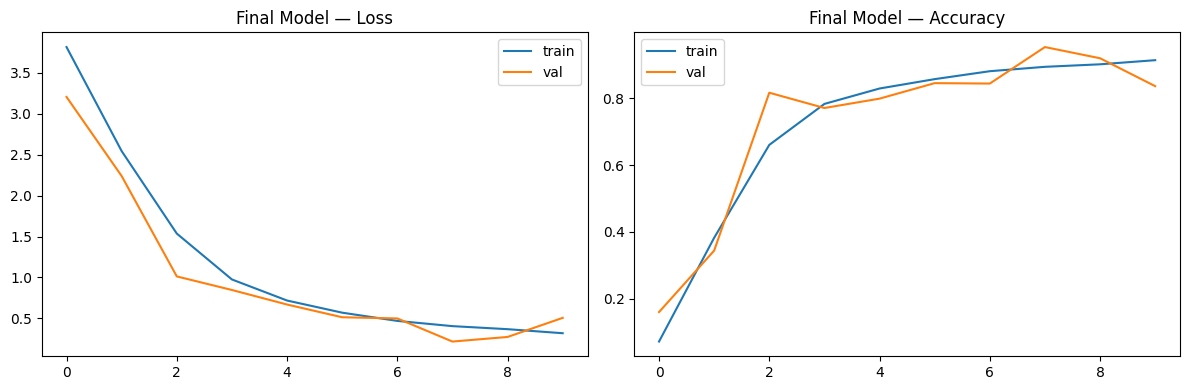

In [15]:
set_seed(CONFIG["seed"])

final_model = CustomCNN(
    num_classes,
    use_batchnorm=True,
    use_dropout=True,
    dropout_p=CONFIG["dropout_p"]
).to(DEVICE)

final_history, final_best_acc, final_best_epoch = train_model(
    final_model,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-3,
    patience=3,
    ckpt_path="../models/final_best.pth"
)

print(f"\nFinal model best val_acc={final_best_acc:.4f} @ epoch {final_best_epoch}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(final_history["train_loss"], label="train"); axes[0].plot(final_history["val_loss"], label="val")
axes[0].set_title("Final Model — Loss"); axes[0].legend()
axes[1].plot(final_history["train_acc"], label="train"); axes[1].plot(final_history["val_acc"], label="val")
axes[1].set_title("Final Model — Accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()

## Test Evaluation

In [17]:
ckpt = torch.load(
    "../models/final_best.pth",
    map_location=DEVICE,
    weights_only=False
)

eval_model = CustomCNN(num_classes, use_batchnorm=True, use_dropout=True).to(DEVICE)
eval_model.load_state_dict(ckpt["state_dict"])
eval_model.eval()

all_preds, all_labels, all_probs, all_images = [], [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        logits = eval_model(images.to(DEVICE))
        probs = F.softmax(logits, dim=1)
        all_preds.append(probs.argmax(1).cpu())
        all_labels.append(labels)
        all_probs.append(probs.cpu())
        all_images.append(images)

preds = torch.cat(all_preds).numpy()
labels_arr = torch.cat(all_labels).numpy()
probs_arr = torch.cat(all_probs).numpy()
images_arr = torch.cat(all_images).numpy()

acc = accuracy_score(labels_arr, preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    labels_arr, preds, average="macro", zero_division=0
)

print(f"Test Accuracy:   {acc:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall:    {recall:.4f}")
print(f"Macro F1:        {f1:.4f}")

Test Accuracy:   0.9545
Macro Precision: 0.9603
Macro Recall:    0.9545
Macro F1:        0.9536


## Confusion Matrix

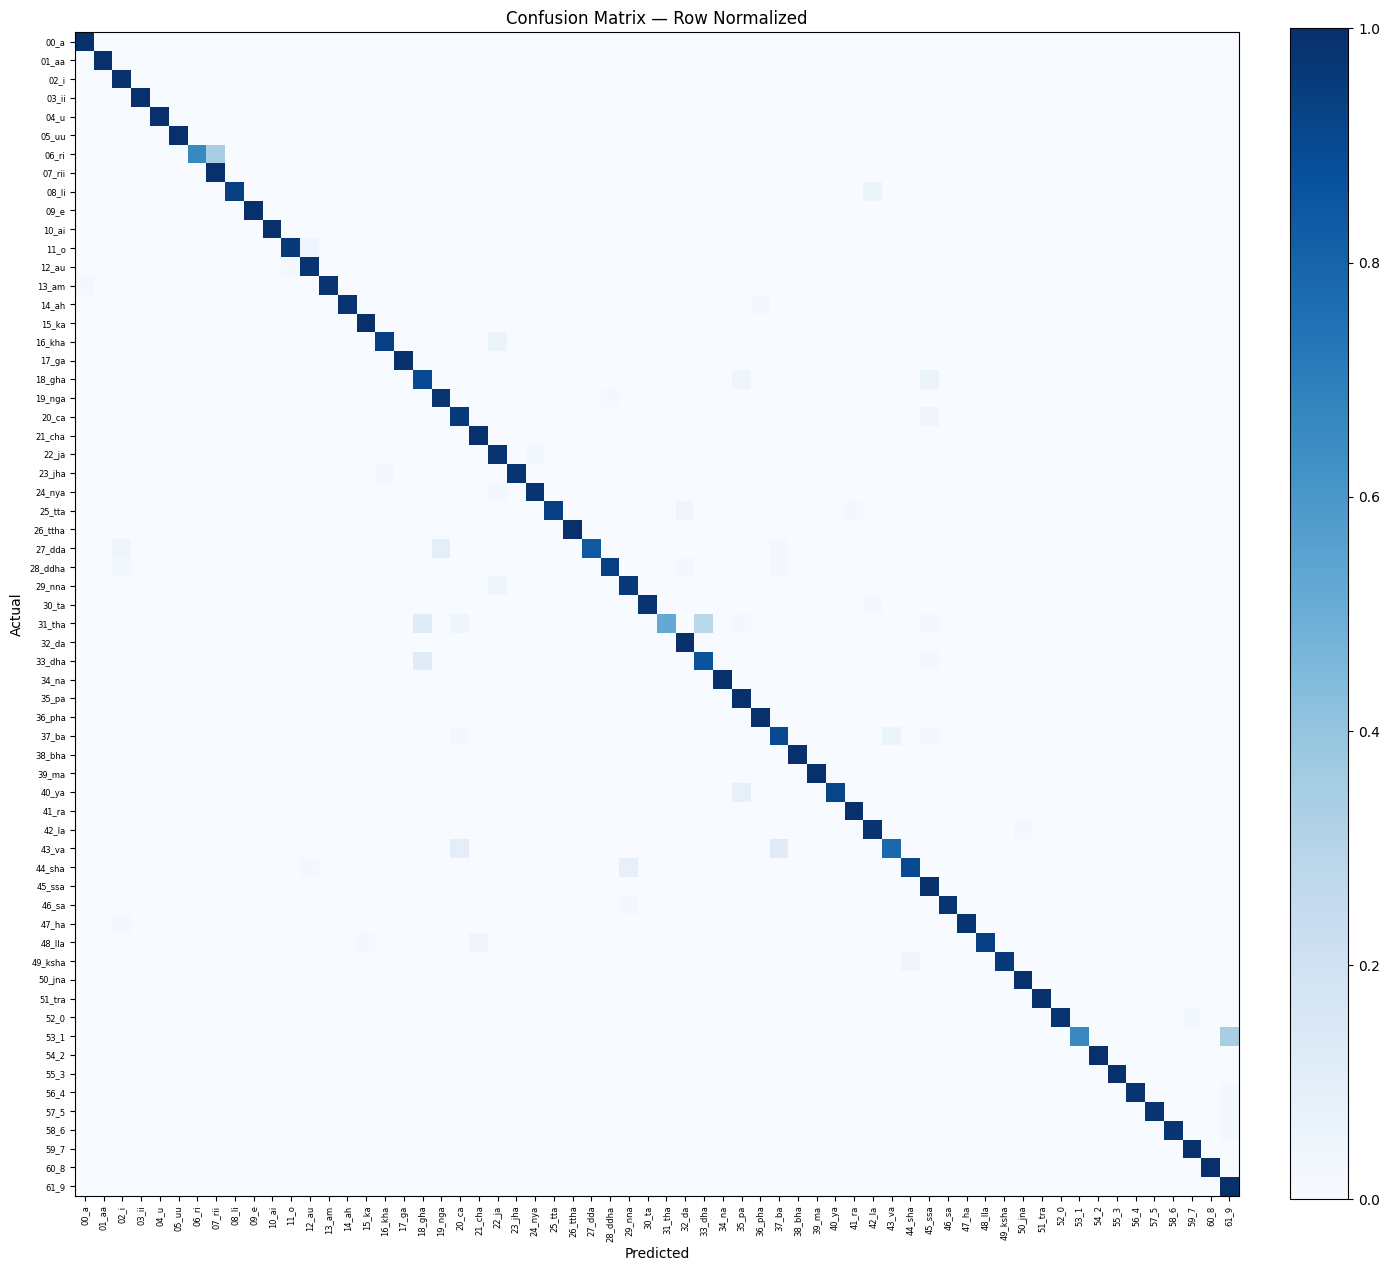

In [22]:
cm = confusion_matrix(labels_arr, preds, labels=list(range(num_classes)))
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(14, 14))
im = ax.imshow(cm_norm, cmap="Blues")

ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=90, fontsize=6)

ax.set_yticks(range(num_classes))
ax.set_yticklabels(class_names, fontsize=6)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

ax.set_title("Confusion Matrix — Row Normalized")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Error Analysis

### Most Confused Classes

In [23]:
pairs = [
    (cm[i, j], class_names[i], class_names[j])
    for i in range(num_classes) for j in range(num_classes)
    if i != j and cm[i, j] > 0
]
pairs.sort(reverse=True)
print("Top 10 confusion pairs:\n")
for count, actual, predicted in pairs[:10]:
    print(f"{actual:>20s} -> {predicted:<20s}  {count}")

Top 10 confusion pairs:

                53_1 -> 61_9                  17
               06_ri -> 07_rii                17
              31_tha -> 33_dha                14
               43_va -> 37_ba                 6
              33_dha -> 18_gha                6
              31_tha -> 18_gha                6
               43_va -> 20_ca                 5
              27_dda -> 19_nga                5
              44_sha -> 29_nna                4
               40_ya -> 35_pa                 4


### Misclassified Examples

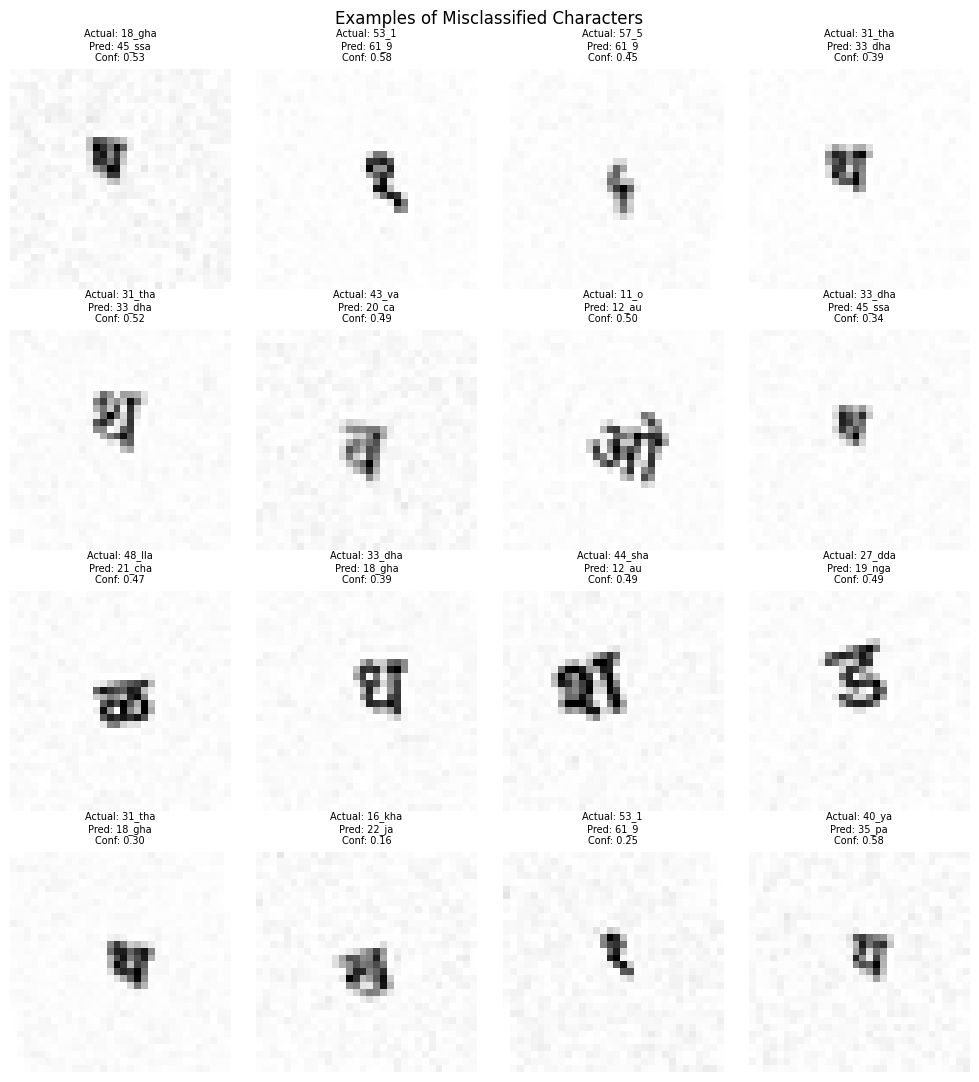

In [24]:
wrong_idx = np.where(preds != labels_arr)[0]
rng = np.random.default_rng(
    CONFIG["seed"]
)
rng.shuffle(wrong_idx)
wrong_idx = wrong_idx[:16]

fig, axes = plt.subplots(4, 4, figsize=(10, 11))
for ax, idx in zip(axes.ravel(), wrong_idx):
    img = images_arr[idx][0] * STD + MEAN
    ax.imshow(img, cmap="gray")
    ax.set_title(
        f"Actual: {class_names[labels_arr[idx]]}\n"
        f"Pred: {class_names[preds[idx]]}\n"
        f"Conf: {probs_arr[idx][preds[idx]]:.2f}",
        fontsize=7
    )
    ax.axis("off")
plt.suptitle("Examples of Misclassified Characters")
plt.tight_layout(); plt.show()

## Model Export

In [25]:
os.makedirs("../models", exist_ok=True)

torch.save({
    "state_dict": eval_model.state_dict(),
    "class_names": class_names,
    "image_size": CONFIG["image_size"],
    "normalize_mean": float(MEAN),
    "normalize_std": float(STD),
    "num_classes": num_classes,
    "use_batchnorm": True,
    "use_dropout": True,
    "dropout_p": CONFIG["dropout_p"],
    "test_accuracy": float(acc),
    "test_macro_precision": float(precision),
    "test_macro_recall": float(recall),
    "test_macro_f1": float(f1),
}, "../models/best_model.pth")

print("Saved to ../models/best_model.pth")

Saved to ../models/best_model.pth


## FastAPI Deployment

In [33]:
%%writefile ../api/main.py
import io
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from PIL import Image
from torchvision import transforms

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_bn, pool):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=not use_bn)
        self.bn = nn.BatchNorm2d(out_ch) if use_bn else nn.Identity()
        self.pool = nn.MaxPool2d(2) if pool else nn.Identity()
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = F.relu(x)
        x = self.pool(x)
        return x

class CustomCNN(nn.Module):
    def __init__(self, num_classes, use_batchnorm=True, use_dropout=True, dropout_p=0.3):
        super().__init__()
        self.block1 = ConvBlock(1, 32, use_batchnorm, pool=True)
        self.block2 = ConvBlock(32, 64, use_batchnorm, pool=True)
        self.block3 = ConvBlock(64, 128, use_batchnorm, pool=False)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout_p) if use_dropout else nn.Identity()
        self.fc = nn.Linear(128, num_classes)
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

BASE_DIR = Path(__file__).resolve().parent.parent
CKPT_PATH = BASE_DIR / "models" / "best_model.pth"

_ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
_class_names = _ckpt["class_names"]
_image_size = _ckpt["image_size"]
_mean = float(_ckpt["normalize_mean"])
_std = float(_ckpt["normalize_std"])

_model = CustomCNN(
    num_classes=len(_class_names),
    use_batchnorm=_ckpt.get("use_batchnorm", True),
    use_dropout=_ckpt.get("use_dropout", True),
    dropout_p=_ckpt.get("dropout_p", 0.3)
)
_model.load_state_dict(_ckpt["state_dict"])
_model.eval()

_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((_image_size, _image_size)),
    transforms.ToTensor(),
    transforms.Normalize((_mean,), (_std,))
])

app = FastAPI(
    title="DevaVision API",
    description="Handwritten Sanskrit character recognition using a CNN",
    version="1.0.0"
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],       # tighten to your Vercel domain before real deployment
    allow_methods=["*"],
    allow_headers=["*"],
)

@app.get("/health")
def health():
    return {"status": "ok", "num_classes": len(_class_names)}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    raw = await file.read()
    img = Image.open(io.BytesIO(raw)).convert("L")
    x = _transform(img).unsqueeze(0)

    with torch.no_grad():
        logits = _model(x)
        probs = F.softmax(logits, dim=1)[0]

    top_probs, top_idx = torch.topk(probs, k=min(3, len(_class_names)))

    return {
        "predicted_class": _class_names[int(top_idx[0])],
        "confidence": float(top_probs[0]),
        "top3": [
            {"class_name": _class_names[int(i)], "confidence": float(p)}
            for p, i in zip(top_probs, top_idx)
        ]
    }

Overwriting ../api/main.py


### API Smoke Test

In [34]:
import sys
sys.path.append("..")

from fastapi.testclient import TestClient
from api.main import app

client = TestClient(app)

health_response = client.get("/health")
print("Health:")
print(health_response.json())

test_base_dataset = test_ds.dataset
test_original_index = test_ds.indices[0]
sample_path = test_base_dataset.samples[test_original_index][0]

print("\nTesting image:")
print(sample_path)

with open(sample_path, "rb") as f:
    response = client.post(
        "/predict",
        files={"file": ("sample.png", f, "image/png")}
    )

print("\nPrediction response:")
print(response.json())
print("\nHTTP status:", response.status_code)

Health:
{'status': 'ok', 'num_classes': 62}

Testing image:
../data/Sanskrit Mnist/images\60_8\60_0270.png

Prediction response:
{'predicted_class': '60_8', 'confidence': 0.9240899085998535}

HTTP status: 200
